Marketing Campaign Performance Insights

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#Load the Dataset
url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv"

df = pd.read_csv(url)

Descriptive Analysis

In [7]:
#Display the First Few Rows
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,01-01-2023
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,01-01-2023
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,01-01-2023
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,01-01-2023
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,01-01-2023


In [8]:
#Get Number of Rows and Columns
df.shape

(22029, 16)

In [9]:
#Get Dataset Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       22029 non-null  int64  
 1   Company           22029 non-null  object 
 2   Campaign_Type     22029 non-null  object 
 3   Target_Audience   22029 non-null  object 
 4   Duration          22029 non-null  object 
 5   Channel_Used      22029 non-null  object 
 6   Conversion_Rate   22029 non-null  float64
 7   Acquisition_Cost  22029 non-null  int64  
 8   ROI               22029 non-null  float64
 9   Location          22029 non-null  object 
 10  Language          22029 non-null  object 
 11  Clicks            22029 non-null  int64  
 12  Impressions       22029 non-null  int64  
 13  Engagement_Score  22029 non-null  int64  
 14  Customer_Segment  22029 non-null  object 
 15  Date              22029 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

In [10]:
#Generate Descriptive Statistics
df.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000
mean,11015.000000,4.757232,5522.740842,182.863648,2223.807572,50610.402787,6.582323
std,6359.368876,0.960393,2597.666260,301.619721,1394.166380,28542.979123,1.458804
min,1.000000,2.015723,1000.000000,-98.300000,30.000000,1001.000000,4.000000
25%,5508.000000,4.130705,3286.000000,-4.080000,1067.000000,25804.000000,5.000000
50%,11015.000000,4.761527,5525.000000,93.650000,2088.000000,50858.000000,7.000000
75%,16522.000000,5.429335,7766.000000,247.310000,3212.000000,75165.000000,8.000000
max,22029.000000,7.469907,9999.000000,3109.790000,6887.000000,99999.000000,9.000000


In [11]:
#Number of Unique Campaign IDs
df['Campaign_ID'].nunique()

22029

In [12]:
#Unique Values in Location
df['Location'].unique()

array(['Houston', 'Washington, D.C.', 'Miami', 'Seattle', 'Chicago',
       'Los Angeles', 'Atlanta', 'Dallas', 'New York', 'San Francisco'],
      dtype=object)

In [13]:
#Unique Values in Customer Segment
df['Customer_Segment'].unique()

array(['Tech Enthusiasts', 'Foodies', 'Fashionistas',
       'Outdoor Adventurers', 'Health & Wellness'], dtype=object)

In [ ]:
#Count of Each Category in Campaign Type
df['Campaign_Type'].value_counts()

,count
Campaign_Type,
Display,4450
Search,4441
Social Media,4412
Email,4388
Influencer,4338


In [14]:
#Count of Each Category in Channel Used
df['Channel_Used'].value_counts()

,count
Channel_Used,
Facebook,3742
Google Ads,3694
Website,3688
Instagram,3649
YouTube,3632
Email,3624


Exploratory Data Analysis (EDA) and Visualization

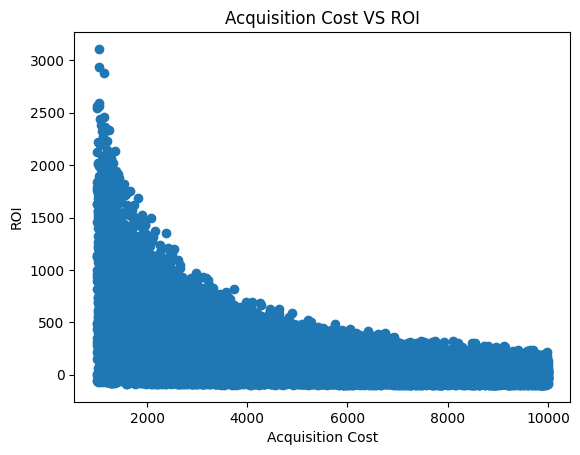

In [15]:
#Scatter Plot: Acquisition Cost vs ROI
plt.figure()
plt.scatter(df['Acquisition_Cost'],df['ROI'])
plt.xlabel('Acquisition Cost')
plt.ylabel('ROI')
plt.title("Acquisition Cost VS ROI")
plt.show()

In [16]:
#Group By
avg_conversion =(
    df.groupby(['Channel_Used','Campaign_Type'])['Conversion_Rate'].mean()
    .reset_index()
)

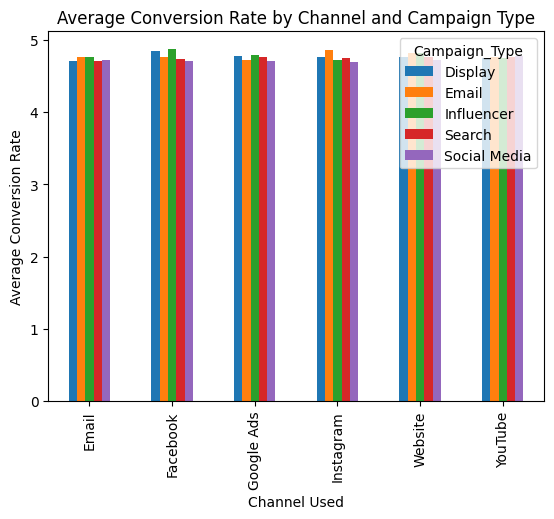

In [18]:
#Bar Chart
avg_conversion.pivot(
    index='Channel_Used',
    columns='Campaign_Type',
    values='Conversion_Rate'
).plot(kind='bar')

plt.xlabel('Channel Used')
plt.ylabel('Average Conversion Rate')
plt.title('Average Conversion Rate by Channel and Campaign Type')
plt.show()

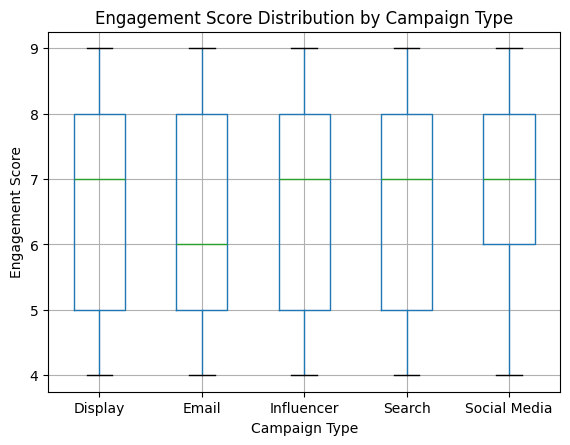

In [27]:
#Box Plot
df.boxplot(column='Engagement_Score',by='Campaign_Type')
plt.xlabel('Campaign Type')
plt.ylabel('Engagement Score')
plt.title('Engagement Score Distribution by Campaign Type')
plt.suptitle('')
plt.show()

In [28]:
#Calculate Average ROI by Company
avg_roi_company = (df.groupby('Company')['ROI'].mean().reset_index())

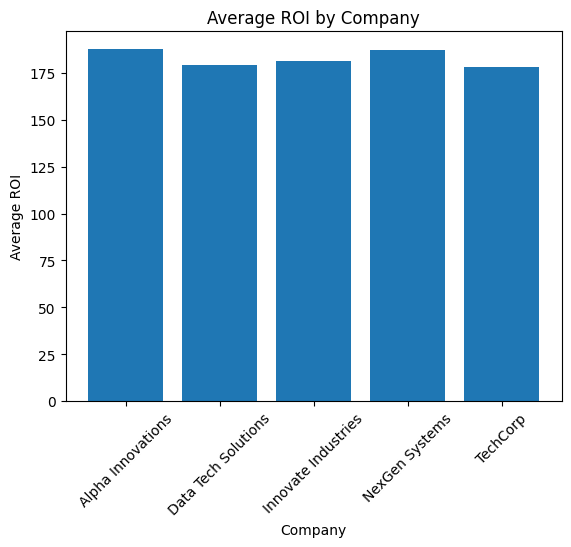

In [29]:
#Bar chart
plt.bar(avg_roi_company['Company'],avg_roi_company['ROI'])
plt.xlabel('Company')
plt.ylabel('Average ROI')
plt.title('Average ROI by Company')
plt.xticks(rotation=45)
plt.show()

In [30]:
#Calculate Correlation
correlation = df[['Engagement_Score', 'Conversion_Rate']].corr()

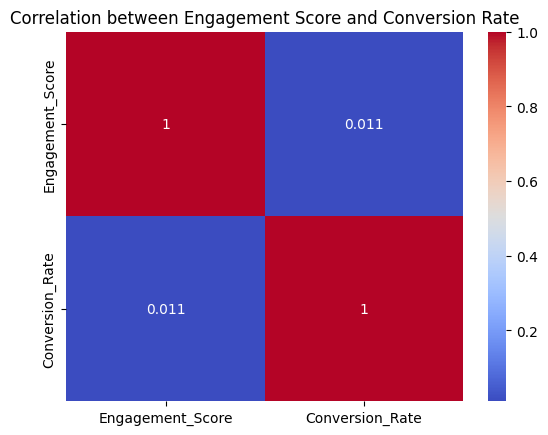

In [32]:
#Heat Map
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Correlation between Engagement Score and Conversion Rate')
plt.show()

Customer Segmentation

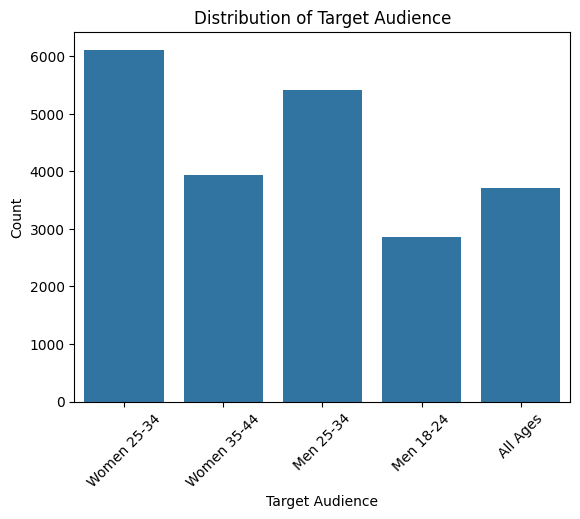

In [33]:
#Count Plot
sns.countplot(x='Target_Audience', data=df)
plt.xlabel('Target Audience')
plt.ylabel('Count')
plt.title('Distribution of Target Audience')
plt.xticks(rotation=45)
plt.show()

In [34]:
#Calculate Average Conversion Rate
avg_conv = (df.groupby(['Language', 'Customer_Segment'])['Conversion_Rate'].mean().reset_index())

In [35]:
#Identify Highest Conversion Rate per Language
top_segments = avg_conv.loc[avg_conv.groupby('Language')['Conversion_Rate'].idxmax()]

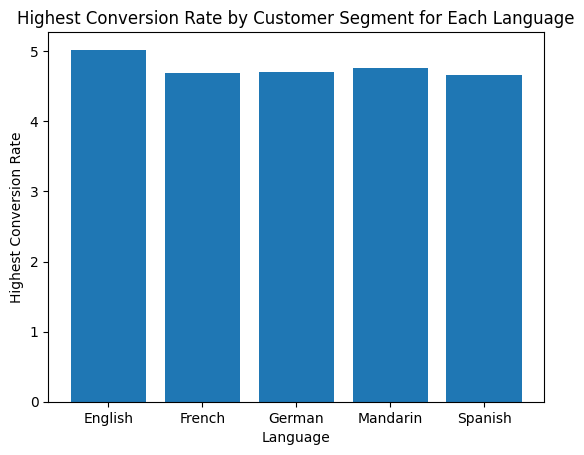

In [36]:
#Bar Chart
plt.bar(top_segments['Language'],top_segments['Conversion_Rate'])
plt.xlabel('Language')
plt.ylabel('Highest Conversion Rate')
plt.title('Highest Conversion Rate by Customer Segment for Each Language')
plt.show()

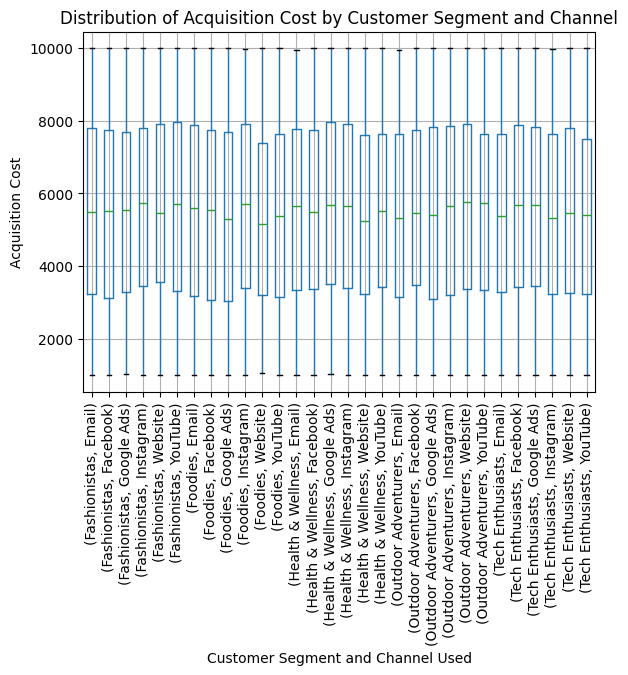

In [44]:
#Box Plot
df.boxplot(column='Acquisition_Cost',by=['Customer_Segment', 'Channel_Used'])
plt.xlabel('Customer Segment and Channel Used')
plt.ylabel('Acquisition Cost')
plt.title('Distribution of Acquisition Cost by Customer Segment and Channel')
plt.suptitle('')
plt.xticks(rotation=90)
plt.show()

In [45]:
#Calculate Average Conversion Rate by Language
avg_conv_language = (df.groupby('Language')['Conversion_Rate'].mean().reset_index())

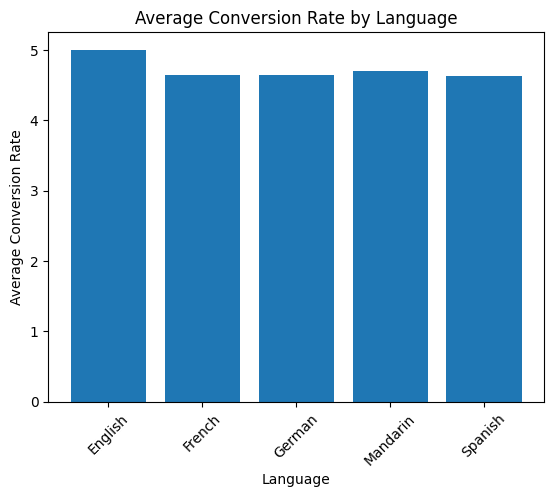

In [46]:
#Bar Chart
plt.bar(avg_conv_language['Language'],avg_conv_language['Conversion_Rate'])
plt.xlabel('Language')
plt.ylabel('Average Conversion Rate')
plt.title('Average Conversion Rate by Language')
plt.xticks(rotation=45)
plt.show()

Channel Effectiveness

In [47]:
#Calculate Average Engagement Score
avg_engagement = (df.groupby(['Channel_Used', 'Campaign_Type'])['Engagement_Score'].mean().reset_index())

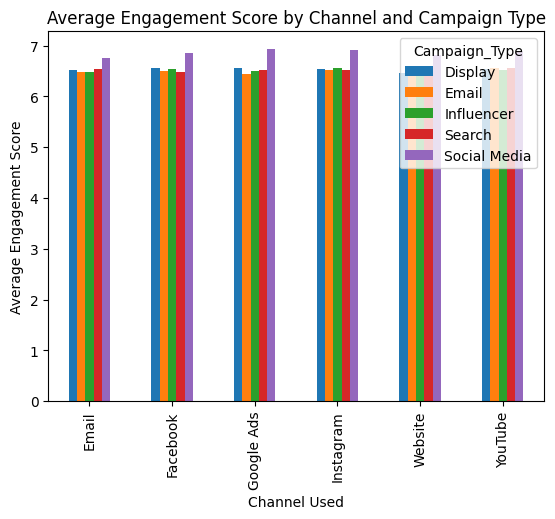

In [48]:
#Bar Chart
avg_engagement.pivot(index='Channel_Used',columns='Campaign_Type',values='Engagement_Score').plot(kind='bar')
plt.xlabel('Channel Used')
plt.ylabel('Average Engagement Score')
plt.title('Average Engagement Score by Channel and Campaign Type')
plt.show()

In [49]:
#Calculate Total ROI by Channel
total_roi_channel = (df.groupby('Channel_Used')['ROI'].sum().reset_index())

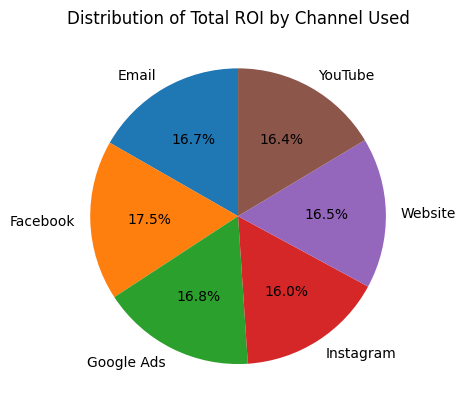

In [50]:
#Pie Chart
plt.pie(total_roi_channel['ROI'],labels=total_roi_channel['Channel_Used'],autopct='%1.1f%%',startangle=90)
plt.title('Distribution of Total ROI by Channel Used')
plt.show()

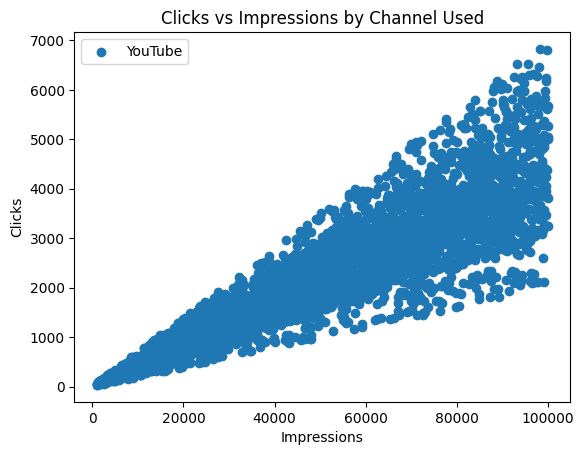

In [51]:
#Scatter Plot
for channel in df['Channel_Used'].unique():
    channel_data = df[df['Channel_Used'] == channel]

plt.scatter(channel_data['Impressions'],channel_data['Clicks'],label=channel)
plt.xlabel('Impressions')
plt.ylabel('Clicks')
plt.title('Clicks vs Impressions by Channel Used')
plt.legend()
plt.show()

Time-Based Analysis

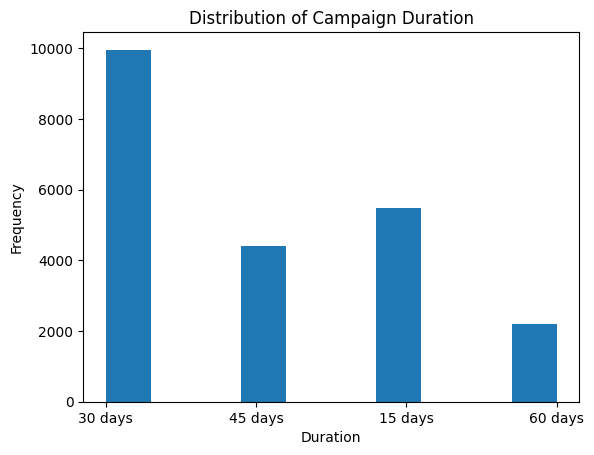

In [52]:
#Histogram
plt.hist(df['Duration'], bins=10)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Distribution of Campaign Duration')
plt.show()

In [60]:
#Average Conversion Rate by Date and Company
conv_trend = (df.groupby(['Date', 'Company'])['Conversion_Rate'].mean().reset_index())

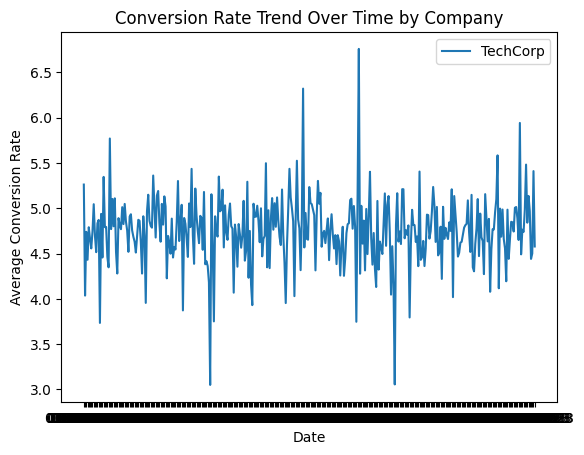

In [59]:
#Line Chart
for company in conv_trend['Company'].unique():
    company_data = conv_trend[conv_trend['Company'] == company]

plt.plot(company_data['Date'],company_data['Conversion_Rate'],label=company)
plt.xlabel('Date')
plt.ylabel('Average Conversion Rate')
plt.title('Conversion Rate Trend Over Time by Company')
plt.legend()
plt.show()

In [62]:
engagement_trend = (df.groupby('Date')['Engagement_Score'].mean().reset_index())

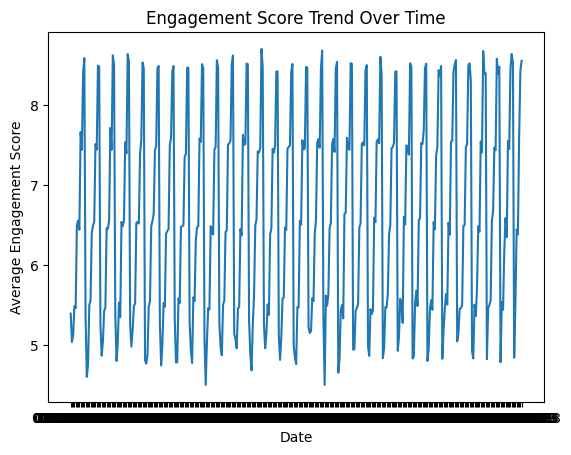

In [63]:
#Line Chart
plt.plot(engagement_trend['Date'],engagement_trend['Engagement_Score'])
plt.xlabel('Date')
plt.ylabel('Average Engagement Score')
plt.title('Engagement Score Trend Over Time')
plt.show()

Geographic Analysis

In [64]:
#Average Acquisition Cost by Location
avg_acq_location = (df.groupby('Location')['Acquisition_Cost'].mean().reset_index())

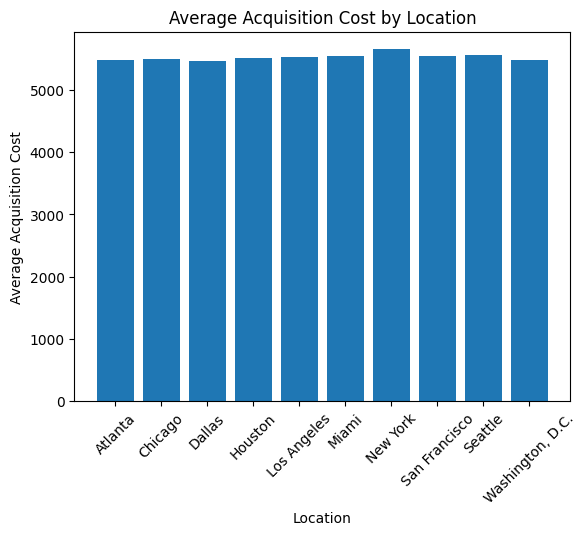

In [65]:
#Bar Chart
plt.bar(avg_acq_location['Location'],avg_acq_location['Acquisition_Cost'])
plt.xlabel('Location')
plt.ylabel('Average Acquisition Cost')
plt.title('Average Acquisition Cost by Location')
plt.xticks(rotation=45)
plt.show()

In [66]:
#Average Conversion Rate
avg_conv = (df.groupby(['Location', 'Target_Audience'])['Conversion_Rate'].mean().reset_index())

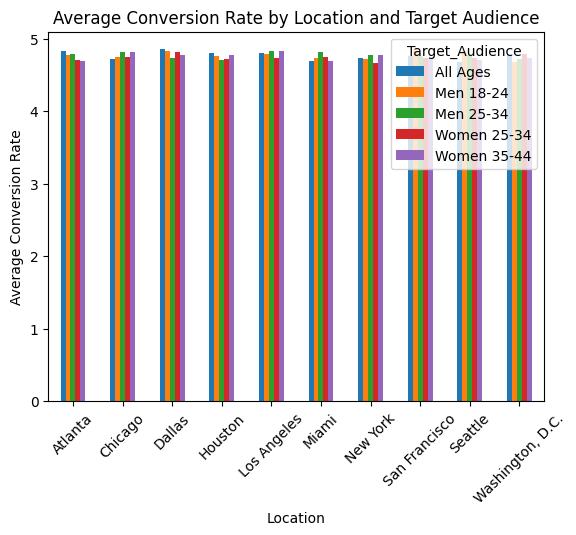

In [67]:
#Bar Chart
avg_conv.pivot(index='Location',columns='Target_Audience',values='Conversion_Rate').plot(kind='bar')
plt.xlabel('Location')
plt.ylabel('Average Conversion Rate')
plt.title('Average Conversion Rate by Location and Target Audience')
plt.xticks(rotation=45)
plt.show()

In [68]:
#Total ROI by Location
total_roi_location = (df.groupby('Location')['ROI'].sum().reset_index())

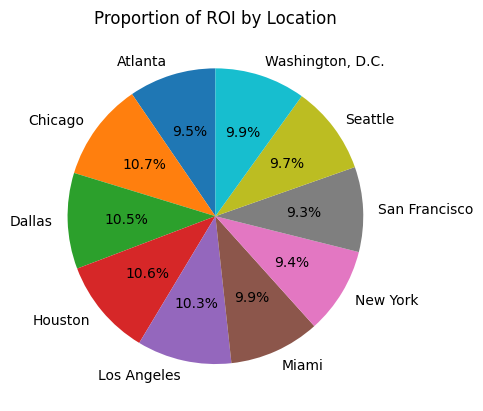

In [69]:
#Pie Chart
plt.pie(total_roi_location['ROI'],labels=total_roi_location['Location'],autopct='%1.1f%%',startangle=90)
plt.title('Proportion of ROI by Location')
plt.show()